# 02 - Medical Dictionary Creation (Hybrid Approach: UMLS + Quantized LLM)

In this notebook, we construct the **Semantic Concept Matrix ($T$)** using a robust, data-driven, and clinically validated pipeline. This matrix serves as the semantic ground truth required for the unsupervised concept discovery and valuation of the Sparse Autoencoder (SAE) latent features.

To ensure strict adherence to medical terminology and eliminate polysemy, the generation pipeline follows a four-stage architecture:

### 1. Dynamic Atomic Extraction (Data-Driven)
Rather than defining a rigid and arbitrary set of medical classes, clinical labels are extracted dynamically from the `Problems` metadata field of the **Open-I dataset**.
* **Polysemy Resolution:** Radiologists frequently concatenate multiple findings within a single record using semicolons (e.g., `"Cardiomegaly;Pulmonary Edema"`). Passing these raw strings would result in tangled, polysemantical text embeddings.
* **Granular Splitting:** The pipeline parses and splits these strings into clean, atomized, and unique clinical concepts, matching the monosemantic nature of the Sparse Autoencoder.

### 2. Ontological Grounding (UMLS API Integration)
To anchor our dictionary to certified medical knowledge, each unique concept is cross-referenced with the **Unified Medical Language System (UMLS)** Terminology Services.
* The script queries the UMLS API to retrieve the official **Concept Unique Identifier (CUI)**.
* Certified synonyms are extracted from standardized clinical ontologies (such as **SNOMED CT** and **MeSH**).
* A robust fallback mechanism preserves the cleaned base term if the API encounters strict formatting mismatches, preventing any data loss.

### 3. Contextual Expansion via Quantized LLM (Llama 3.1)
Vision-Language Models (VLMs) like BioMedCLIP perform optimal text-image alignment when fed descriptive, narrative phrases rather than isolated medical keywords.
* **4-bit Quantization:** To fit within the constraints of Google Colab's 15GB T4 GPU VRAM, **Meta Llama 3.1 8B Instruct** is loaded utilizing `BitsAndBytesConfig` in 4-bit precision.
* **Prompt Engineering:** The LLM acts as an expert radiologist, transforming UMLS synonyms into 5 short, realistic, and visually-focused sentences typical of a chest X-ray report.
* **VRAM Optimization:** After generation, the LLM pipeline is explicitly deleted from memory, and `torch.cuda.empty_cache()` is invoked to free the VRAM for the subsequent embedding model.

### 4. Semantic Centroid Extraction (BioMedCLIP Text Embedding)
The contextually expanded phrases are processed through the specialized textual encoder of **BioMedCLIP** (underpinned by PubMedBERT with a 256-token context window).
* **Mean Pooling:** For each medical concept, the pipeline tokenizes and encodes all its generated descriptive phrases, calculating the mathematical mean of their vectors to produce a highly stable **Semantic Centroid**.
* **Double L2 Normalization:** Embeddings are normalized both before and after the pooling operation, projecting the final text vectors onto the L2 unit sphere.

The resulting structured dictionary is saved as `biomedclip_medical_dictionary_embeddings.pt`. It represents a mathematically rigorous and multimodally aligned space, perfectly prepared to evaluate the interpretability of the SAE features.

## Architectural Transition: Adapting to Open-I and BioMedCLIP

This notebook has been fundamentally restructured to transition from the legacy NIH/PubMedCLIP pipeline to a modern, data-driven architecture powered by the **Open-I dataset** and **BioMedCLIP**. The original implementation suffered from structural flaws that have been systematically resolved:

### 1. From Hardcoded to Data-Driven Labels
* **Old Flaw:** The pipeline relied on the fixed 14 pathological classes inherited from the NIH dataset.
* **Solution:** We implemented **Dynamic Atomic Extraction** from the Open-I `Problems` metadata field. By parsing and splitting physician-entered clinical findings via semicolons, the vocabulary is completely derived from real-world patient data, ensuring scientific integrity.

### 2. Eliminating Domain-Specific Hacks (`context_corrections`)
* **Old Flaw:** A rigid dictionary mapping was used to force abstract terms into specific pulmonary contexts (e.g., mapping `"Effusion"` to `"Pleural Effusion"`) because of the poor granularity of NIH labels.
* **Solution:** Since Open-I contains precise clinical nomenclature, this manual mapping was removed to avoid semantic distortion. The **UMLS Recovery Pass** was kept purely as a defensive formatting filter to guarantee pipeline resilience.

### 3. Preserving Semantic Mapping via Centroid Pooling
* **Old Flaw:** The expanded sentences generated by the LLM were flattened into a single list (`medical_dictionary`), completely severing the link between descriptive phrases and their ground-truth clinical labels.
* **Solution:** The dictionary structure `{'concept': [phrases]}` is strictly preserved. Leveraging BioMedCLIP's advanced text encoder (underpinned by PubMedBERT), we encode all descriptive phrases per concept and apply **Mean Pooling followed by double L2 normalization**. This yields a highly stable **Semantic Centroid** for each pathology, ensuring a flawless visual-textual alignment for the Sparse Autoencoder evaluation.

## Visual Feature Extraction (Vision-Language Alignment)

**Note on the Dataset (NIH Chest X-ray14 - 10k Subset):**
For this project, we chose not to process the entire original NIH dataset (112,120 images, ~42 GB) to comply with memory and execution constraints (timeouts) on Google Colab.
We use a stratified and balanced subset of 10,000 samples (`g-ronimo/NIH-Chest-X-ray-dataset_10k`), derived directly from the official data. This volume is statistically sufficient for our *proof-of-concept*: our goal is not to train a visual classifier from scratch, but to allow the loss function of a *Sparse Autoencoder* (SAE) to converge by leveraging a pre-trained latent space (PubMed CLIP).

In [1]:
# Setup and installation of required libraries
!pip install -q transformers accelerate bitsandbytes datasets huggingface_hub requests python-dotenv


In [2]:
import sys
import os

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    from google.colab import userdata
    drive.mount('/content/drive')
    save_dir = '/content/drive/MyDrive/xai-project5/results/02_dictionary_creation'

    # Reading secrets from Google Colab
    UMLS_API_KEY = userdata.get('UMLS_API_KEY')
    HF_TOKEN = userdata.get('HF_TOKEN')
else:
    from dotenv import load_dotenv
    load_dotenv() # Load from .env file in the project folder

    save_dir = os.path.abspath(os.path.join('..', 'results', '02_dictionary_creation'))
    UMLS_API_KEY = os.getenv('UMLS_API_KEY')
    HF_TOKEN = os.getenv('HF_TOKEN')

os.makedirs(save_dir, exist_ok=True)
print(f"Save directory configured at: {save_dir}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save directory configured at: /content/drive/MyDrive/xai-project5/results/02_dictionary_creation


## 1. Dynamic Label Extraction
Instead of hardcoding the categories (e.g., "Cardiomegaly", "Atelectasis"), we load the Hugging Face dataset metadata to programmatically extract the original classes on which the dataset was annotated.

In [ ]:
from datasets import load_dataset

print("Reading metadata from the original dataset...")
# We load only the structure, without downloading images again (streaming or empty split)
dataset_meta = load_dataset("ykumards/open-i", split="train")


Reading metadata from the original dataset...


In [4]:
dataset_meta[:]["Problems"]

['normal',
 'Cardiomegaly;Pulmonary Artery',
 'normal',
 'Pulmonary Disease, Chronic Obstructive;Bullous Emphysema;Pulmonary Fibrosis;Cicatrix;Opacity;Opacity;Opacity;Opacity',
 'Osteophyte;Thickening;Lung',
 'normal',
 'Pulmonary Atelectasis;Spondylosis;Arthritis',
 'normal',
 'Calcified Granuloma;Density',
 'Calcified Granuloma',
 'normal',
 'normal',
 'Cardiac Shadow',
 'Lung;Markings',
 'Granulomatous Disease',
 'normal',
 'normal',
 'Pleural Effusion',
 'Aorta, Thoracic;Thoracic Vertebrae',
 'normal',
 'Calcified Granuloma;Breast Implants;Deformity',
 'normal',
 'normal',
 'normal',
 'Sutures;Lung, Hyperlucent;Lung;Pulmonary Emphysema;Airspace Disease;Pleural Effusion;Pleural Effusion',
 'Spondylosis',
 'Lung;Diaphragm;Thoracic Vertebrae',
 'Opacity;Pulmonary Atelectasis;Consolidation;Pulmonary Congestion;Cardiac Shadow',
 'Cardiomegaly;Diaphragm;Tube, Inserted;Airspace Disease',
 'normal',
 'Markings',
 'Costophrenic Angle',
 'Surgical Instruments',
 'normal',
 'Lung;Diaphragm;Th

In [ ]:
concepts=set()

for item in dataset_meta[:]["Probl" \
"ems"]:
    if item != "normal":
        parts=item.split(";")
        for p in parts:
            subparts=p.split(",")
            for s in subparts:
                clean_p=s.strip().lower()
                concepts.add(clean_p)

dynamic_labels=sorted(list(concepts))

print(f"Totale concetti clinici atomici e unici estratti: {len(dynamic_labels)}")
print("\nPrime 20 etichette estratte (esempi):")
print(dynamic_labels[:20])

Totale concetti clinici atomici e unici estratti: 127

Prime 20 etichette estratte (esempi):
['abdomen', 'adipose tissue', 'airspace disease', 'aorta', 'aortic aneurysm', 'arthritis', 'atherosclerosis', 'blister', 'blood vessels', 'bone', 'bone and bones', 'bone diseases', 'breast implants', 'bronchiectasis', 'bronchiolitis', 'bronchitis', 'bullous emphysema', 'calcified granuloma', 'calcinosis', 'cardiac shadow']


In [6]:
# Dynamic label extraction (the 14 original classes)
dynamic_labels = dynamic_labels[:14]

# We remove the "No Finding" class if we only want to focus on pathologies
dynamic_labels = [label for label in dynamic_labels if label != "No Finding"]

print(f"Extracted {len(dynamic_labels)} pathological classes directly from metadata:")
print(dynamic_labels)


Extracted 14 pathological classes directly from metadata:
['abdomen', 'adipose tissue', 'airspace disease', 'aorta', 'aortic aneurysm', 'arthritis', 'atherosclerosis', 'blister', 'blood vessels', 'bone', 'bone and bones', 'bone diseases', 'breast implants', 'bronchiectasis']


## 2. UMLS API Query (Semantic Ground Truth)
We define functions to communicate with the UMLS Terminology Services portal.
- `get_umls_cui`: Finds the exact Concept Unique Identifier (CUI) for the pathology.
- `get_umls_synonyms`: Extracts all official synonyms associated with that CUI, filtering out noise.

In [7]:
import os
import requests
import json

BASE_URL = "https://uts-ws.nlm.nih.gov/rest"

def get_umls_cui(term: str, api_key: str) -> str:
    endpoint = f"{BASE_URL}/search/current"
    params = {
        "string": term,
        "apiKey": api_key,
        "searchType": "exact"
    }
    response = requests.get(endpoint, params=params)
    if response.status_code == 200:
        results = response.json().get('result', {}).get('results', [])
        if results:
            return results[0]['ui']
    return None

def get_umls_synonyms(cui: str, api_key: str):
    endpoint = f"{BASE_URL}/content/current/CUI/{cui}/atoms"
    params = {
        "apiKey": api_key,
        "language": "ENG",
        "sabs": "SNOMEDCT_US,MSH" # Force search only on the cleanest vocabularies (SNOMED and MeSH)
    }
    response = requests.get(endpoint, params=params)
    synonyms = set()

    if response.status_code == 200:
        results = response.json().get('result', [])
        for item in results:
            name = item.get('name', '')
            # Filter to avoid technical codes or incomprehensible acronyms
            if name and len(name) < 40 and "[" not in name and "-" not in name:
                synonyms.add(name.lower())
    return list(synonyms)

print("Starting UMLS API queries...")
umls_checkpoint_path = os.path.join(save_dir, 'umls_checkpoint.json')
umls_clinical_dictionary = {}
failed_labels = [] # Initialize the list to store failed extractions

# Resume from checkpoint if it exists
if os.path.exists(umls_checkpoint_path):
    print("Found UMLS checkpoint! Resuming...")
    with open(umls_checkpoint_path, 'r', encoding='utf-8') as f:
        umls_clinical_dictionary = json.load(f)

for label in dynamic_labels:
    search_term = label.replace("_", " ")

    if label in umls_clinical_dictionary:
        print(f"⏩ Skipping {label}, already in checkpoint.")
        # Check if it was a failure in the checkpoint so we don't lose the failed label
        saved_syns = umls_clinical_dictionary[label]
        if len(saved_syns) == 0 or saved_syns == [search_term.lower()]:
            failed_labels.append(label)
        continue

    # Some NIH labels have an underscore (e.g., "Pleural_Thickening"), we clean it up for the search
    cui = get_umls_cui(search_term, UMLS_API_KEY)

    if cui:
        syns = get_umls_synonyms(cui, UMLS_API_KEY)
        umls_clinical_dictionary[label] = syns

        if len(syns) > 0:
            print(f"✅ {label} (CUI: {cui}) -> Found {len(syns)} certified synonyms.")
        else:
            print(f"⚠️ {label} (CUI: {cui}) -> Found 0 certified synonyms. Added to failed labels.")
            failed_labels.append(label)
    else:
        print(f"❌ No CUI found for {label}. The base term will be kept.")
        umls_clinical_dictionary[label] = [search_term.lower()]
        failed_labels.append(label) # Add to failed list if no CUI is found

    # Save checkpoint after each API request
    with open(umls_checkpoint_path, 'w', encoding='utf-8') as f:
        json.dump(umls_clinical_dictionary, f, indent=4)

print(f"\nFirst pass completed. Failed labels to correct: {failed_labels}")

Starting UMLS API queries...
Found UMLS checkpoint! Resuming...
⏩ Skipping abdomen, already in checkpoint.
⏩ Skipping adipose tissue, already in checkpoint.
⏩ Skipping airspace disease, already in checkpoint.
⏩ Skipping aorta, already in checkpoint.
⏩ Skipping aortic aneurysm, already in checkpoint.
⏩ Skipping arthritis, already in checkpoint.
⏩ Skipping atherosclerosis, already in checkpoint.
⏩ Skipping blister, already in checkpoint.
⏩ Skipping blood vessels, already in checkpoint.
⏩ Skipping bone, already in checkpoint.
⏩ Skipping bone and bones, already in checkpoint.
⏩ Skipping bone diseases, already in checkpoint.
⏩ Skipping breast implants, already in checkpoint.
⏩ Skipping bronchiectasis, already in checkpoint.

First pass completed. Failed labels to correct: ['abdomen', 'airspace disease', 'blister']


To query the UMLS API effectively, we must apply **Domain Alignment**. The NIH dataset contains labels that are specific to chest X-rays, but terms like "Mass", "Edema", or "Effusion" are highly ambiguous in a universal medical metathesaurus like UMLS.

Passing these terms raw results in context mismatch (e.g., "Mass" mapping to a generic physics concept, returning zero clinical synonyms). To resolve this, we map ambiguous labels to their precise thoracic/pulmonary counterparts (e.g., "Pulmonary Mass", "Pleural Effusion"). This guarantees that the retrieved Concept Unique Identifiers (CUIs) and their synonyms belong to the correct clinical domain without introducing synthetic or hallucinated data.

In [8]:
# Contextual correction map ONLY for terms we know are ambiguous

print("Starting Second Pass (Contextual Correction)...")

for label in failed_labels:
    # If we mapped a correction, we use it. Otherwise, we keep the base name.
    corrected_term = label.strip().replace("_", " ")

    print(f"Recovery attempt for '{label}' searching for context: '{corrected_term}'...")

    cui = get_umls_cui(corrected_term, UMLS_API_KEY)

    if cui:
        syns = get_umls_synonyms(cui, UMLS_API_KEY)
        if len(syns) > 0:
            umls_clinical_dictionary[label] = syns
            print(f"   ✅ Recovery Successful! Found {len(syns)} synonyms.")
        else:
            print(f"   ❌ Recovery Failed. UMLS has no valid synonyms. Keeping the base term.")
            umls_clinical_dictionary[label] = [corrected_term.lower()]
    else:
        print(f"   ❌ Recovery Failed. No CUI found. Keeping the base term.")
        umls_clinical_dictionary[label] = [corrected_term.lower()]

# Final checkpoint save
import json
import os

umls_checkpoint_path = os.path.join(save_dir, 'umls_checkpoint.json')
with open(umls_checkpoint_path, 'w', encoding='utf-8') as f:
    json.dump(umls_clinical_dictionary, f, indent=4)

print(f"\nUMLS Dictionary completed and successfully saved! Total classes processed: {len(umls_clinical_dictionary)}")

Starting Second Pass (Contextual Correction)...
Recovery attempt for 'abdomen' searching for context: 'abdomen'...
   ❌ Recovery Failed. UMLS has no valid synonyms. Keeping the base term.
Recovery attempt for 'airspace disease' searching for context: 'airspace disease'...
   ❌ Recovery Failed. No CUI found. Keeping the base term.
Recovery attempt for 'blister' searching for context: 'blister'...
   ❌ Recovery Failed. UMLS has no valid synonyms. Keeping the base term.

UMLS Dictionary completed and successfully saved! Total classes processed: 14


## 3. LLM Initialization (Zephyr-7b or Llama-3.1 in 8-bit)
We load an open-source language model optimized to fit within the RAM of Colab's T4 GPU. This LLM will be tasked with "reading" the UMLS synonyms and constructing narrative sentences typical of medical reports.

In [15]:
# Installazione e aggiornamento delle librerie fondamentali per la quantizzazione e l'accelerazione hardware
!pip install -U bitsandbytes>=0.46.1 transformers accelerate

In [9]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, BitsAndBytesConfig
from huggingface_hub import login

# Hugging Face Authentication (Mandatory to access Meta models)
if HF_TOKEN:
    login(token=HF_TOKEN)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device in use: {device}")

# We use Llama 3.1 8B Instruct (requires HF approval)
model_id = "meta-llama/Meta-Llama-3.1-8B-Instruct"

print("Loading the LLM model in 8-bit mode...")

# Llama-specific tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)

# MODERN APPROACH: Use BitsAndBytesConfig for quantization
# Original: quant_config = BitsAndBytesConfig(load_in_8bit=True)
# Fix: Try 4-bit quantization to further reduce memory usage if 8-bit causes OOM
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# Quantized loading to fit in the 15GB of Colab's T4 GPU
llm_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=quant_config,
    device_map="auto"
)

# Pipeline optimized for Llama 3.1 instructions
pipe = pipeline(
    "text-generation",
    model=llm_model,
    tokenizer=tokenizer,
    max_new_tokens=256, # Reduce to avoid unnecessarily long outputs
    temperature=0.6,    # Slightly lower temperature for more precise clinical responses
    top_p=0.9
)
print("Meta Llama 3.1 loaded and ready to use!")

Device in use: cuda
Loading the LLM model in 8-bit mode...


model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'max_new_tokens', 'top_p'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Meta Llama 3.1 loaded and ready to use!


## 4. Contextual Expansion of the Dictionary
We merge the clinical rigidity of UMLS with the linguistic flexibility of the LLM. For each pathology, we provide the LLM with official synonyms and ask it to generate realistic phrases a radiologist would use in a report.

In [10]:
import os
import json
import re
import torch
import gc

# Assicuriamoci che la cartella di salvataggio esista
save_dir = "../results/dictionary"
os.makedirs(save_dir, exist_ok=True)

llm_checkpoint_path = os.path.join(save_dir, 'llm_checkpoint.json')
expanded_dictionary_dict = {}

# Recupero dal checkpoint per evitare di ricominciare da zero
if os.path.exists(llm_checkpoint_path):
    print("Trovato checkpoint LLM! Riprendo la generazione...")
    with open(llm_checkpoint_path, 'r', encoding='utf-8') as f:
        expanded_dictionary_dict = json.load(f)

print("Generazione frasi radiologiche con Llama 3.1 in corso...\n")

for label, synonyms in umls_clinical_dictionary.items():
    if label in expanded_dictionary_dict:
        print(f"⏩ Salto '{label}', già espanso nel checkpoint.")
        continue

    # Passiamo all'LLM i primi sinonimi per dare contesto clinico
    core_terms = ", ".join(synonyms[:5]) if synonyms else label.replace("_", " ")

    # Abbiamo ridotto a 5 frasi. Chiederne 10 aumenta le allucinazioni e satura il contesto
    messages = [
        {"role": "system", "content": "You are an expert radiologist. I will give you a core medical concept and its official UMLS synonyms. Write exactly 5 short, realistic sentences that a radiologist would use in a chest X-ray report to describe this concept. Focus on visual features. Output ONLY a numbered list. No introductions, no explanations."},
        {"role": "user", "content": f"Concept: '{label}'. Official Synonyms: {core_terms}"}
    ]

    # Utilizziamo la pipeline in modo nativo senza slicing manuale
    outputs = pipe(messages, max_new_tokens=150, return_full_text=False)
    response = outputs[0]['generated_text'].strip()

    current_label_phrases = set()

    # Includiamo i sinonimi ufficiali per ancorare saldamente lo spazio semantico
    if synonyms:
        current_label_phrases.update(synonyms[:3])

    # Parsing rigoroso tramite Regex
    lines = response.split('\n')
    for line in lines:
        # Rimuove numeri iniziali, punti, parentesi o asterischi
        clean_phrase = re.sub(r"^(\d+[\.\)]|\*|-)\s*", "", line).strip()
        # Rimuove eventuali grassetti Markdown residui
        clean_phrase = clean_phrase.replace('"', '').replace('**', '')

        if clean_phrase and len(clean_phrase) > 5:
            current_label_phrases.add(clean_phrase.lower())

    # Manteniamo la STRUTTURA A DIZIONARIO (Fondamentale!)
    expanded_dictionary_dict[label] = list(current_label_phrases)
    print(f"Elaborato '{label}' -> Estratte {len(current_label_phrases)} varianti semantiche.")

    with open(llm_checkpoint_path, 'w', encoding='utf-8') as f:
        json.dump(expanded_dictionary_dict, f, indent=4)

print(f"\nEspansione LLM completata! {len(expanded_dictionary_dict)} concetti medici codificati.")

# Svuotamento critico della memoria GPU per BioMedCLIP
print("\nSvuotamento della memoria VRAM in corso...")
del llm_model
del pipe
gc.collect()
torch.cuda.empty_cache()
print("Memoria GPU liberata con successo. Pronti per l'estrazione visiva!")

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


Generazione frasi radiologiche con Llama 3.1 in corso...



[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Setting `pad_token_id` to `eos_token_id`:128001 fo

Elaborato 'abdomen' -> Estratte 6 varianti semantiche.


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

Elaborato 'bone and bones' -> Estratte 8 varianti semantiche.


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Elaborato 'bone diseases' -> Estratte 8 varianti semantiche.


[transformers] Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Elaborato 'breast implants' -> Estratte 8 varianti semantiche.
Elaborato 'bronchiectasis' -> Estratte 8 varianti semantiche.

Espansione LLM completata! 14 concetti medici codificati.

Svuotamento della memoria VRAM in corso...
Memoria GPU liberata con successo. Pronti per l'estrazione visiva!


## 5. Data Analysis and Visualization
Let's visualize the results of our dictionary generation process. We will plot the number of semantic phrases per pathology and the distribution of token lengths to ensure the generated vocabulary is rich and properly formatted.

Analisi statistica su 14 concetti clinici espansi.
Totale frasi radiologiche uniche generate: 106


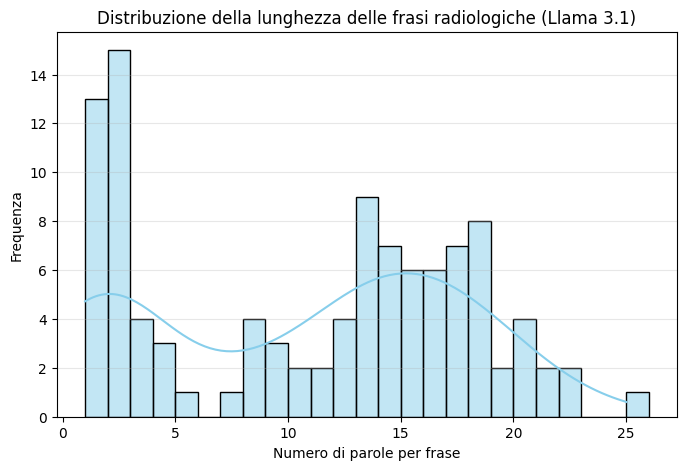

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print(f"Analisi statistica su {len(expanded_dictionary_dict)} concetti clinici espansi.")

# 1. Estraiamo tutte le frasi in una lista temporanea SOLO per le statistiche
all_phrases = []
for phrases in expanded_dictionary_dict.values():
    all_phrases.extend(phrases)

print(f"Totale frasi radiologiche uniche generate: {len(all_phrases)}")

# Plot: Distribuzione della lunghezza delle frasi (conteggio parole)
phrase_lengths = [len(phrase.split()) for phrase in all_phrases]

if phrase_lengths: # Controllo di sicurezza
    plt.figure(figsize=(8, 5))
    sns.histplot(phrase_lengths, bins=range(1, max(phrase_lengths)+2), kde=True, color="skyblue")

    plt.title("Distribuzione della lunghezza delle frasi radiologiche (Llama 3.1)", fontsize=12)
    plt.xlabel("Numero di parole per frase", fontsize=10)
    plt.ylabel("Frequenza", fontsize=10)
    plt.grid(axis='y', alpha=0.3)

    # Mostriamo il grafico
    plt.show()
else:
    print("Nessuna frase trovata per generare il grafico.")


## 6. Encoding and Exporting the $T$ Matrix
Finally, we translate the generated phrases into mathematical vectors using the PubMed CLIP Text Encoder. The resulting matrix ($T$) will be normalized and saved to be used in the Sparse Autoencoder training notebook.

In [16]:
!pip install open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.3 MB/s eta 0:00:00


In [17]:
import torch
import torch.nn.functional as F
import open_clip
import os

# Assicuriamoci che device sia definito
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device in uso: {device}")

print("Caricamento dell'encoder testuale di BioMedCLIP...")
model_name = "hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224"
clip_model, _, _ = open_clip.create_model_and_transforms(model_name)
clip_model = clip_model.to(device)
clip_model.eval()

tokenizer_clip = open_clip.get_tokenizer(model_name)

# Il nostro nuovo dizionario finale: { 'concetto': tensore_medio_normalizzato }
final_concept_embeddings = {}

save_path = os.path.join(save_dir, 'biomedclip_medical_dictionary_embeddings.pt')
print(f"\nCalcolo degli embedding e dei centroidi semantici per {len(expanded_dictionary_dict)} concetti...")

with torch.no_grad():
    for concept, phrases in expanded_dictionary_dict.items():
        if not phrases:
            print(f" Attenzione: Nessuna frase trovata per '{concept}'. Salto.")
            continue

        # 1. Tokenizziamo TUTTE le frasi associate a questo specifico concetto medico
        # BioMedCLIP accetta fino a 256 token, perfetto per le nostre frasi descrittive
        text_tokens = tokenizer_clip(phrases).to(device)

        # 2. Estraiamo i vettori per ogni frase
        text_features = clip_model.encode_text(text_tokens)

        # 3. Normalizziamo ogni singolo vettore (prassi standard prima della media)
        text_features_normalized = F.normalize(text_features, p=2, dim=1)

        # 4. Calcoliamo il "Centroide": la media matematica di tutte le frasi
        mean_embedding = torch.mean(text_features_normalized, dim=0, keepdim=True)

        # 5. Ri-normalizziamo il vettore medio finale sulla sfera unitaria L2 (Cruciale!)
        final_embedding = F.normalize(mean_embedding, p=2, dim=1)

        # Salviamo nel dizionario associandolo al nome pulito della patologia
        final_concept_embeddings[concept] = final_embedding.cpu()

# Salvataggio del dizionario strutturato
torch.save(final_concept_embeddings, save_path)

print(f"\n✅ Operazione completata con successo!")
print(f"Dizionario BioMedCLIP salvato in: {save_path}")

# Stampiamo una verifica finale per confermare la shape
sample_concept = list(final_concept_embeddings.keys())[0]
sample_shape = final_concept_embeddings[sample_concept].shape
print(f"Shape del tensore per singolo concetto: {sample_shape}")

Device in uso: cuda
Caricamento dell'encoder testuale di BioMedCLIP...


open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin:   0%|          | 0.00/784M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/225k [00:00<?, ?B/s]


Calcolo degli embedding e dei centroidi semantici per 14 concetti...

✅ Operazione completata con successo!
Dizionario BioMedCLIP salvato in: ../results/dictionary/biomedclip_medical_dictionary_embeddings.pt
Shape del tensore per singolo concetto: torch.Size([1, 512])
